In [ ]:
# The goal of this notebook is to analyse stats over the season,, majorly using table 
#Player_gameweek_score

In [20]:
import pymysql
import pandas as pd
import os
from sqlalchemy import Integer, String, create_engine, select,text,distinct
from sqlalchemy.orm import Session,DeclarativeBase,sessionmaker
from sqlalchemy import URL

a = pymysql.connect(host="localhost",database="fpl", user="root", password="password")

In [21]:
def create_connection_engine(db, host = "localhost", user = "root", password = "password"):
    """Creates a SQLAlchemy engine with a mysql database"""

    url_object = URL.create(
        "mysql+pymysql",
        username=user,
        password=password, 
        host=host,
        database=db)

    return create_engine(url_object)

session = sessionmaker(create_connection_engine('fpl'))

READING FROM DATABASE

In [32]:
query_1 = text("select * from Player_gameweek_score")
obj = session.execute(query_1).all()

columns = ["index","player_id","minutes","goals_scored","assists","clean_sheets","goals_conceded","own_goals","penalties_saved","penalties_missed","yellow_cards","red_cards","saves","bonus","bps ","influence","creativity","threat","ict_index","starts","expected_goals","expected_assists","expected_goal_involvements","expected_goals_conceded","total_points","in_dreamteam","gameweek","team","position"]

df = pd.DataFrame(obj, columns=columns)
df = df.drop(labels="index", axis = 1)
df = df.set_index("player_id")

print(len(df))
df.head()

28804


,minutes,goals_scored,assists,clean_sheets,goals_conceded,own_goals,penalties_saved,penalties_missed,yellow_cards,red_cards,...,starts,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,total_points,in_dreamteam,gameweek,team,position
player_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Forward
2,0,0,0,0,0,0,0,0,0,0,...,0,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Defender
3,0,0,0,0,0,0,0,0,0,0,...,0,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Midfielder
4,0,0,0,0,0,0,0,0,0,0,...,0,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Midfielder
5,4,0,0,0,0,0,0,0,0,0,...,0,0.00,0.00,0.00,0.02,1,0,1,Arsenal,Defender


In [92]:
#fixture_df

fixture_query = text("select * from Fixtures_table")
obj = session.execute(fixture_query).all()

columns = ["index","code","event","finished","fixture_id","kickoff_time","minutes","team_a","team_a_score","team_h_score","team_h","team_h_difficulty","team_a_difficulty"]
fixtures_df = pd.DataFrame(obj, columns= columns)


fixtures_df.head()

,index,code,event,finished,fixture_id,kickoff_time,minutes,team_a,team_a_score,team_h_score,team_h,team_h_difficulty,team_a_difficulty,month,year
0,0,2367538,1,1,1,2023-08-11 19:00:00,90,13,3.0,0.0,6,5,2,August,2023
1,1,2367540,1,1,2,2023-08-12 12:00:00,90,16,1.0,2.0,1,2,5,August,2023
2,2,2367539,1,1,3,2023-08-12 14:00:00,90,19,1.0,1.0,3,2,2,August,2023
3,3,2367541,1,1,4,2023-08-12 14:00:00,90,12,1.0,4.0,5,2,3,August,2023
4,4,2367542,1,1,5,2023-08-12 14:00:00,90,10,1.0,0.0,9,2,2,August,2023


In [65]:
#Player to team relation for 1st half and 2nd half of the season

team_1_query = text("select * from EPL_PLAYERS_2023_1ST_HALF")
team_2_query = text("select * from EPL_PLAYERS_2023_2ND_HALF")

obj = session.execute(team_1_query).all()

columns_1 = ["player_id","team","position","player_name","team_code"]
columns_2 = ["player_id","team_code","team","position","player_name"]
team_1_df = pd.DataFrame(obj, columns= columns_1)

obj = session.execute(team_2_query).all()
team_2_df = pd.DataFrame(obj, columns= columns_2)

team_1_df = team_1_df[columns_2]

,player_id,team_code,team,position,player_name
0,1,1,Arsenal,Forward,Folarin Balogun
1,2,1,Arsenal,Defender,Cédric Alves Soares
2,3,1,Arsenal,Midfielder,Mohamed Elneny
3,4,1,Arsenal,Midfielder,Fábio Ferreira Vieira
4,5,1,Arsenal,Defender,Gabriel dos Santos Magalhães


COMBINING TABLES

In [62]:
team_code_df = team_2_df[['team', 'team_code']].drop_duplicates()
team_code_key = {i.team_code:i.team for i in team_code_df.itertuples()}

del team_code_df
team_code_key

try :
    fixtures_df['team_a'] = fixtures_df['team_a'].map(lambda x: team_code_key[x])
except KeyError:
    pass

try :
    fixtures_df['team_h'] = fixtures_df['team_h'].map(lambda x: team_code_key[x])
except KeyError:
    pass

del team_code_key

fixtures_df["kickoff_time"] = fixtures_df["kickoff_time"].astype("datetime64[h]")


MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
fixtures_df['month'] = fixtures_df['kickoff_time'].map(lambda x: MONTHS[x.month - 1])
fixtures_df['year'] = fixtures_df['kickoff_time'].map(lambda x: x.year)

fixtures_df.head()

,index,code,event,finished,fixture_id,kickoff_time,minutes,team_a,team_a_score,team_h_score,team_h,team_h_difficulty,team_a_difficulty
0,0,2367538,1,1,1,2023-08-11T19:00:00Z,90,Man City,3.0,0.0,Burnley,5,2
1,1,2367540,1,1,2,2023-08-12T12:00:00Z,90,Nott'm Forest,1.0,2.0,Arsenal,2,5
2,2,2367539,1,1,3,2023-08-12T14:00:00Z,90,West Ham,1.0,1.0,Bournemouth,2,2
3,3,2367541,1,1,4,2023-08-12T14:00:00Z,90,Luton,1.0,4.0,Brighton,2,3
4,4,2367542,1,1,5,2023-08-12T14:00:00Z,90,Fulham,1.0,0.0,Everton,2,2


In [ ]:
player_id_name_df = team_1_df[['player_id', 'player_name']].drop_duplicates()
player_id_name_2_df = team_2_df[['player_id', 'player_name']].drop_duplicates()

player_id_key = {i.player_id:i.player_name for i in player_id_name_df.itertuples()}
player_id_key_2 = {i.player_id:i.player_name for i in player_id_name_2_df.itertuples()}

del player_id_name_df
del player_id_name_2_df

#player_id_key
try:
    df['player_name'] = df.index.map(lambda x: player_id_key[x])
except KeyError:
    df['player_name'] = df.index.map(lambda x: player_id_key_2[x])

del team_1_df
del team_2_df


In [97]:
df.head()

,minutes,goals_scored,assists,clean_sheets,goals_conceded,own_goals,penalties_saved,penalties_missed,yellow_cards,red_cards,...,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,total_points,in_dreamteam,gameweek,team,position,player_name
player_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Forward,Folarin Balogun
2,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Defender,Cédric Alves Soares
3,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Midfielder,Mohamed Elneny
4,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,0,0,1,Arsenal,Midfielder,Fábio Ferreira Vieira
5,4,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0.00,0.02,1,0,1,Arsenal,Defender,Gabriel dos Santos Magalhães


In [ ]:
a = df.query("in_dreamteam > 0")

In [119]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
You should consider upgrading via the '/Users/max/Desktop/Sports/temp_env/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


<Axes: >

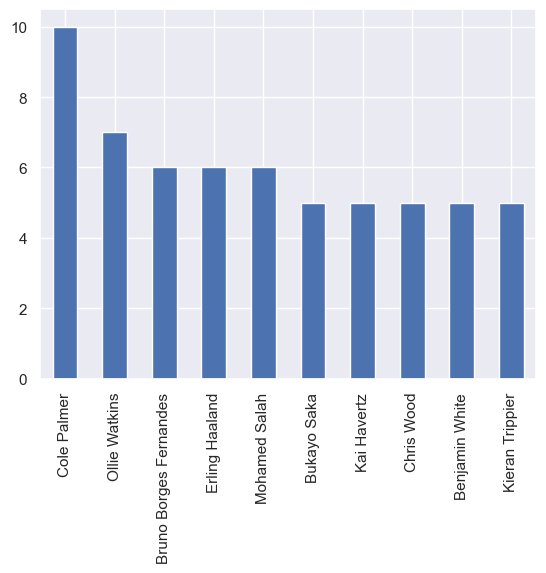

In [120]:
import seaborn as sns
sns.set_theme("notebook")

a['player_name'].value_counts(ascending=False).head(n= 10).plot(kind='bar')

#Definition of Talisman

<Axes: >

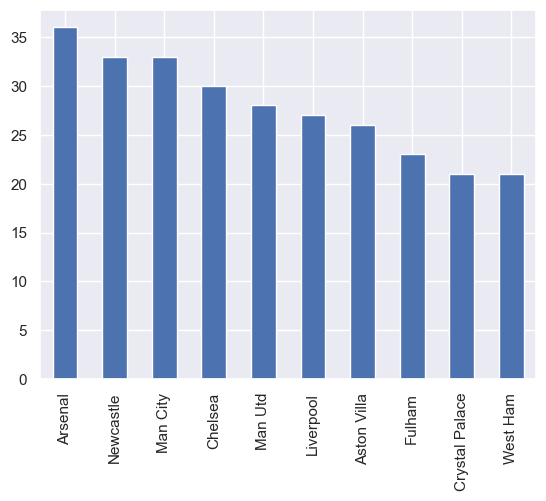

In [121]:
a['team'].value_counts(ascending=False).head(n= 10).plot(kind='bar')

<Axes: >

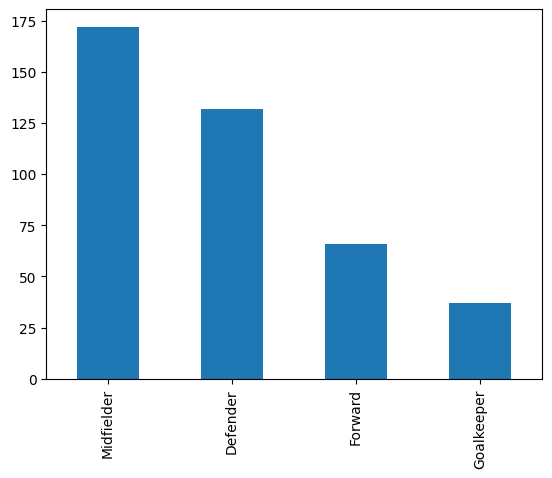

In [117]:
a['position'].value_counts(ascending=False).head(n= 10).plot(kind='bar')

#Display dominant names perhaps identify with colors. #PowerBi maybe better for this visualization/

TOTAL POINTS


In [181]:
df.drop_duplicates().groupby('team').aggregate(sum)[['total_points', 'goals_scored', 'assists', 'in_dreamteam']].sort_values(by="total_points")

/var/folders/3v/kl4z85b17kd84k1hy0srlb3w0000gn/T/ipykernel_1997/1580217010.py:1: FutureWarning: The operation <built-in function sum> failed on a column. If any error is raised, this will raise an exception in a future version of pandas. Drop these columns to avoid this warning.
  df.drop_duplicates().groupby('team').aggregate(sum)[['total_points', 'goals_scored', 'assists', 'in_dreamteam']].sort_values(by="total_points")


,total_points,goals_scored,assists,in_dreamteam
team,,,,
Sheffield Utd,1025,34,32,5
Burnley,1248,40,36,7
Nott'm Forest,1408,49,46,18
Luton,1413,56,52,13
Brighton,1445,49,46,14
Brentford,1501,54,43,12
Wolves,1523,55,53,18
Everton,1550,40,24,17
West Ham,1555,59,51,24


In [140]:
df = df.merge(fixtures_df[['month', 'event']], how='left', left_on= 'gameweek', right_on='event')

In [169]:
df.head()

,minutes,goals_scored,assists,clean_sheets,goals_conceded,own_goals,penalties_saved,penalties_missed,yellow_cards,red_cards,...,expected_goal_involvements,expected_goals_conceded,total_points,in_dreamteam,gameweek,team,position,player_name,month,event
0,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0,0,1,Arsenal,Forward,Folarin Balogun,August,1
1,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0,0,1,Arsenal,Forward,Folarin Balogun,August,1
2,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0,0,1,Arsenal,Forward,Folarin Balogun,August,1
3,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0,0,1,Arsenal,Forward,Folarin Balogun,August,1
4,0,0,0,0,0,0,0,0,0,0,...,0.00,0.00,0,0,1,Arsenal,Forward,Folarin Balogun,August,1


In [180]:
goalkeeper_df = df[df["position"] == "Goalkeeper"][df['assists'] > 0]
#goalkeeper_df.groupby('month', as_index = True).aggregate("sum")['assists']

#goalkeeper_df.drop_duplicates()


/var/folders/3v/kl4z85b17kd84k1hy0srlb3w0000gn/T/ipykernel_1997/2768807442.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  goalkeeper_df = df[df["position"] == "Goalkeeper"][df['assists'] > 0]


,minutes,goals_scored,assists,clean_sheets,goals_conceded,own_goals,penalties_saved,penalties_missed,yellow_cards,red_cards,...,expected_goal_involvements,expected_goals_conceded,total_points,in_dreamteam,gameweek,team,position,player_name,month,event
161658,90,0,1,0,3,0,0,0,0,0,...,0.01,2.15,10,1,23,Brentford,Goalkeeper,Mark Flekken,February,23
245278,90,0,1,0,2,0,0,0,0,0,...,0.00,1.90,8,0,33,Wolves,Goalkeeper,José Malheiro de Sá,April,33
